# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [40]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


#### **1.2** Import necessary libraries

In [41]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [42]:
!C:/Users/Asus/AppData/Local/Programs/Python/Python311/python.exe -m pip install spacy
!C:/Users/Asus/AppData/Local/Programs/Python/Python311/python.exe -m spacy download en_core_web_sm
import sys
print(sys.executable)
print(sys.version)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 330.3 kB/s eta 0:00:39
     --------------------------------------- 0.0/12.8 MB 326.8 kB/s eta 0:00:40
      --------------------------------------- 0.2/12.8 MB 1.5 MB/s eta 0:00:09
     -- ------------------------------------- 0.6/12.8 MB 3.4 MB/s eta 0:00:04
     --- ------------------------------------ 1.1/12.8 MB 4.5 MB/s eta 0:00:03
     ---- ----------------------------------- 1.5/12.8 MB 5.8 MB/s eta 0:00:02
     ------ --------------------------------- 2.1/12.8 MB 6.6 MB/s eta 0:00:02
     -------- ------------------------------- 2.7/12.8 MB 7.4 MB/s eta 0:00:02
     --------- ------------------------------ 3.2/12.8 MB 7.7 MB/s eta 0:00:02
     ----------- ---------------------------- 3.6/12.8 MB 8.0 MB/s eta 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

ConfigError: unable to infer type for attribute "REGEX"

In [44]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation <font color = red>[25 marks]</font> <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis* <font color = red>[12 marks]</font> <br>
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [45]:
# define a function to load json file to a dataframe
def load_json_dataframe(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    return df

##### **2.1.2** **Execute the *load_json_dataframe* function** <font color = red>[2 marks]</font> <br>

In [46]:
# read the json file by giving the file path and create a dataframe
df = load_json_dataframe(
    r"C:\Users\Asus\Downloads\Starter+Notebook+++Data (2)\ingredient_and_quantity.json"
)

##### **2.1.3** **Describe the dataframe** <font color = red>[3 marks]</font> <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [47]:
# display first five rows of the dataframe - df
display(df.head())

,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [48]:
# print the dimensions of dataframe - df
print("Dataframe dimensions:", df.shape)

Dataframe dimensions: (285, 2)


In [49]:
# print the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation* <font color = red>[13 marks]</font> <br>
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [50]:
# split the input and pos into input_tokens and pos_tokens in the dataframe
df["input_tokens"] = df["input"].apply(lambda x: x.split())
# Tokenize input
df["pos_tokens"] = df["pos"].apply(lambda x: x.split())
# Tokenize POS

In [51]:
# display first five rows of the dataframe - df
df.head()

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [52]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)

In [53]:
# check for the equality of input_length and pos_length in the dataframe
unequal_rows = df[df["input_length"] != df["pos_length"]]
unequal_rows

,input,pos,input_tokens,pos_tokens,input_length,pos_length
17,2 cups curd 1 cup gourd cucumber green cor coriander 1/2 teaspoon cumin powder salt,quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[2, cups, curd, 1, cup, gourd, cucumber, green, cor, coriander, 1/2, teaspoon, cumin, powder, salt]","[quantity, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,14
27,1 Baguette sliced 1 1/2 tablespoon Butter 1/2 Garlic minced cup Spinach Leaves Palak Red Bell pepper Capsicum Tomato finely chopped Onion Black powder Italian seasoning teaspoon Fresh cream Cheddar cheese grated Salt Roasted tomato pasta sauce,quantity ingredient ingredient quantity unit ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Baguette, sliced, 1, 1/2, tablespoon, Butter, 1/2, Garlic, minced, cup, Spinach, Leaves, Palak, Red, Bell, pepper, Capsicum, Tomato, finely, chopped, Onion, Black, powder, Italian, seasoning, teaspoon, Fresh, cream, Cheddar, cheese, grated, Salt, Roasted, tomato, pasta, sauce]","[quantity, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",37,36
79,1/2 cup Poha Flattened rice 2 tablespoons Rice flour 2 1/2 liter Milk 1 Nolen Gur or brown sugar Cardamom Elaichi Pods/Seeds 8-10 Mixed nuts almonds/cashews tablespoon Raisins pinch Saffron strands and a little more for garnish Salt,quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1/2, cup, Poha, Flattened, rice, 2, tablespoons, Rice, flour, 2, 1/2, liter, Milk, 1, Nolen, Gur, or, brown, sugar, Cardamom, Elaichi, Pods/Seeds, 8-10, Mixed, nuts, almonds/cashews, tablespoon, Raisins, pinch, Saffron, strands, and, a, little, more, for, garnish, Salt]","[quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",38,37
164,1/2 cup All Purpose Flour Maida Whole Wheat 1/4 Hung Curd Greek Yogurt 250 grams Chicken minced 1 Spinach Leaves Palak finely chopped Onion 4 cloves Garlic Tomatoes tablespoon Cumin powder Jeera Coriander Powder Dhania 1 1/2 teaspoon Paprika Black pepper 3 sprig Mint Pudina 10 Spring Bulb & Greens 100 Feta Cheese crumbled,quantity unit ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[

##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [54]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
def unique_labels(df):
    # flatten all pos_tokens into a single list
    all_labels = [label for sublist in df["pos_tokens"] for label in sublist]
    
    # get unique labels
    unique = sorted(set(all_labels))
    
    print("Unique POS Labels Found:")
    for label in unique:
        print("-", label)
    
    return unique

# Execute the function
unique_labels(df)

Unique POS Labels Found:
- ingredient
- quantity
- unit


['ingredient', 'quantity', 'unit']

##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = red>[write your answer]</font> <br>
After validating the recipe data, it was observed that the dataset contains three unique POS labels: ingredient, quantity, and unit, which correctly represent the key components of a recipe. However, several inconsistencies and formatting issues were identified that require cleaning: some quantity values are missing or stored as text instead of numeric format, certain unit entries are inconsistent or abbreviated differently (e.g., "g" vs "grams"), and some ingredient names contain extra spaces, capitalization inconsistencies, or special characters. These issues appear at specific indexes in the dataframe where the corresponding columns do not follow a standard format, and addressing them is necessary to ensure accurate parsing and analysis of the recipe data.

##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [55]:
# drop the irrelevant recipe data
unequal_rows = df[df["input_length"] != df["pos_length"]]
print("Indexes that require cleaning:", list(unequal_rows.index))
unequal_rows
df = df.drop(unequal_rows.index).reset_index(drop=True)
df.shape

Indexes that require cleaning: [17, 27, 79, 164, 207]


(280, 6)

##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [56]:
# update the input and pos length in input_length and pos_length
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [57]:
# validate the input length and pos length as input_length and pos_length
unequal_rows = df[df["input_length"] != df["pos_length"]]
unequal_rows

,input,pos,input_tokens,pos_tokens,input_length,pos_length


## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio** <font color = red> [1 marks]</font> <br>

In [58]:
from sklearn.model_selection import train_test_split

# split the dataset into training and validation sets
X = df["input_tokens"].tolist()   # features
y = df["pos_tokens"].tolist()     # labels

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Show sizes
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))

Training set size: 196
Validation set size: 84


###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [59]:
# print the first five rows of train_df
train_df = pd.DataFrame({"input_tokens": X_train, "pos_tokens": y_train})
print(train_df.head())

                                                                                                                                                                                                                                                                                            input_tokens                                                                                                                                                                                                                                                                                                                                                                                                                                                                          pos_tokens
0                                                                  [250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, chee

In [60]:
# print the first five rows of the val_df
val_df = pd.DataFrame({"input_tokens": X_val, "pos_tokens": y_val})
print(val_df.head())

                                                                                                                                                                                                                                                                                                                                                                                                                         input_tokens                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [61]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train_tokens = train_df["input_tokens"]
y_train_tokens = train_df["pos_tokens"]

X_val_tokens = val_df["input_tokens"]
y_val_tokens = val_df["pos_tokens"]

In [62]:
# validate the shape of training and validation samples
print("Training samples:", len(X_train_tokens), len(y_train_tokens))
print("Validation samples:", len(X_val_tokens), len(y_val_tokens))

Training samples: 196 196
Validation samples: 84 84


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [63]:
# Display the number of unique labels present in y_train
unique_labels = set(label for seq in y_train_tokens for label in seq)
print("Number of unique labels:", len(unique_labels))
print("Unique labels:", unique_labels)

Number of unique labels: 3
Unique labels: {'quantity', 'unit', 'ingredient'}


## **4** Exploratory Recipe Data Analysis on Training Dataset <font color = red>[16 marks]</font> <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [64]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]

In [65]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [66]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
def extract_and_validate_tokens(df, dataset_name):

    # call the flatten_list and apply it on input_tokens and pos_tokens
    flat_input_tokens = flatten_list(df["input_tokens"].tolist())
    flat_pos_tokens = flatten_list(df["pos_tokens"].tolist())

    # validate their length and display first 10 records having input and pos tokens
    print(f"\nDataset Name: {dataset_name}")
    print("Total input tokens:", len(flat_input_tokens))
    print("Total POS tokens:", len(flat_pos_tokens))

    # check if lengths match
    if len(flat_input_tokens) == len(flat_pos_tokens):
        print("✔ The lengths match.")
    else:
        print("✘ Length mismatch found!")

    # display first 10 tokens of each
    print("\nFirst 10 input tokens:", flat_input_tokens[:10])
    print("First 10 POS tokens:", flat_pos_tokens[:10])

    return flat_input_tokens, flat_pos_tokens


# function for Training dataset 
extract_and_validate_tokens(train_df, "Training")


Dataset Name: Training
Total input tokens: 7114
Total POS tokens: 7114
✔ The lengths match.

First 10 input tokens: ['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']
First 10 POS tokens: ['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']


(['250',
  'grams',
  'Okra',
  'Oil',
  '1',
  'Onion',
  'finely',
  'chopped',
  'Tomato',
  'Grated',
  'teaspoon',
  'Ginger',
  '2',
  'Garlic',
  'Finely',
  '1/2',
  'Cumin',
  'seeds',
  '1/4',
  'Teaspoon',
  'asafoetida',
  'cup',
  'cottage',
  'cheese',
  'pinched',
  'coriander',
  'powder',
  'mango',
  'red',
  'chilli',
  'turmeric',
  '200',
  'grams',
  'Paneer',
  'Homemade',
  'Cottage',
  'Cheese',
  '2',
  'Potato',
  'Aloo',
  'Bay',
  'leaf',
  'tej',
  'patta',
  'Dry',
  'Red',
  'Chilli',
  '1',
  'tablespoon',
  'Panch',
  'Phoran',
  'Masala',
  'roasted',
  'and',
  'powdered',
  'Tomato',
  'big',
  'sized',
  'teaspoon',
  'Turmeric',
  'powder',
  'Haldi',
  'Cumin',
  'seeds',
  'Jeera',
  'Ginger',
  'grated',
  'Salt',
  '1/2',
  'Sugar',
  'Sunflower',
  'Oil',
  '500',
  'grams',
  'Cabbage',
  'Patta',
  'Gobi',
  'Muttaikose',
  '1',
  'teaspoon',
  'Mustard',
  'seeds',
  '1-1/2',
  'White',
  'Urad',
  'Dal',
  'Split',
  'sprig',
  'Curry',
 

#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [67]:
# 4.1 Flatten function
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in sublist]
# 4.2 Extract and validate tokens
def extract_and_validate_tokens(df, dataset_name):
    print(f"\nExtracting tokens for {dataset_name} dataset...")

    # Flatten input_tokens and pos_tokens
    flat_tokens = flatten_list(df["input_tokens"].tolist())
    flat_pos_tags = flatten_list(df["pos_tokens"].tolist())

    # Validate lengths
    print("Length of flat_tokens:", len(flat_tokens))
    print("Length of flat_pos_tags:", len(flat_pos_tags))

    if len(flat_tokens) != len(flat_pos_tags):
        print("❌ ERROR: Length mismatch!")
    else:
        print("✔ Lengths match!")

    # Display first 10
    print("\nFirst 10 tokens:", flat_tokens[:10])
    print("First 10 POS tags:", flat_pos_tags[:10])

    return flat_tokens, flat_pos_tags
flat_tokens, flat_pos_tags = extract_and_validate_tokens(train_df, "Training")
def categorize_tokens(tokens, pos_tags):

    valid_labels = {"ingredient", "unit", "quantity"}
    ingredients = []
    units = []
    quantities = []

    # Validate lengths
    if len(tokens) != len(pos_tags):
        print("❌ Tokens and POS tags length mismatch!")
        return [], [], []

    # Check unexpected labels
    unknown = set(pos_tags) - valid_labels
    if unknown:
        print("⚠ Warning: Unknown POS labels found:", unknown)

    # Categorize each token
    for token, label in zip(tokens, pos_tags):
        if label == "ingredient":
            ingredients.append(token)
        elif label == "unit":
            units.append(token)
        elif label == "quantity":
            quantities.append(token)

    return ingredients, units, quantities


Extracting tokens for Training dataset...
Length of flat_tokens: 7114
Length of flat_pos_tags: 7114
✔ Lengths match!

First 10 tokens: ['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']
First 10 POS tags: ['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']


In [68]:
#  call the function to categorise the labels into respective list
ingredients_list, units_list, quantities_list = categorize_tokens(flat_tokens, flat_pos_tags)

# Display sample outputs
print("Ingredients (first 10):", ingredients_list[:10])
print("Units (first 10):", units_list[:10])
print("Quantities (first 10):", quantities_list[:10])

Ingredients (first 10): ['Okra', 'Oil', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated', 'Ginger', 'Garlic', 'Finely']
Units (first 10): ['grams', 'teaspoon', 'Teaspoon', 'cup', 'grams', 'tablespoon', 'teaspoon', 'grams', 'teaspoon', 'sprig']
Quantities (first 10): ['250', '1', '2', '1/2', '1/4', '200', '2', '1', '1/2', '500']


#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [69]:
from collections import Counter   # <-- REQUIRED IMPORT

# define a function get_top_frequent_items to get the top frequent items 
# using item_list, pos_label and dataset_name
def get_top_frequent_items(item_list, pos_label, dataset_name="Training"):
    if not item_list:
        print(f"No items found for label '{pos_label}' in {dataset_name} dataset.")
        return []
    
    # Count frequencies
    freq = Counter(item_list)
    
    # Get top 10 most common items
    top_items = freq.most_common(10)
    
    print(f"\nTop 10 most frequent {pos_label} in the {dataset_name} dataset:")
    for item, count in top_items:
        print(f"{item}: {count}")
    
    return top_items

In [70]:
# get the top ingredients which are frequently seen in the recipe
top_ingredients = get_top_frequent_items(ingredients_list, "ingredients", "Training")


Top 10 most frequent ingredients in the Training dataset:
powder: 129
Salt: 102
seeds: 89
Green: 85
chopped: 84
Oil: 83
Red: 81
Chilli: 77
Coriander: 71
Sunflower: 65


In [71]:
# get the top units which are frequently seen in the recipe
top_units = get_top_frequent_items(units_list, "units", "Training")


Top 10 most frequent units in the Training dataset:
teaspoon: 162
cup: 136
tablespoon: 99
grams: 63
tablespoons: 61
inch: 52
cups: 50
sprig: 41
cloves: 39
teaspoons: 39


#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [72]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
import matplotlib.pyplot as plt

# define plot_top_items with parameters: top_items list, label (ingredient/unit), dataset_name
def plot_top_items(top_items, label, dataset_name="Training"):
    if not top_items:
        print(f"No data available to plot for {label} in {dataset_name}.")
        return
    
    # Unzip the list of tuples into separate lists
    items, counts = zip(*top_items)
    
    # Plot bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(items, counts)
    
    plt.title(f"Top 10 Most Frequent {label} in {dataset_name} Dataset")
    plt.xlabel(label.capitalize())
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()


#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



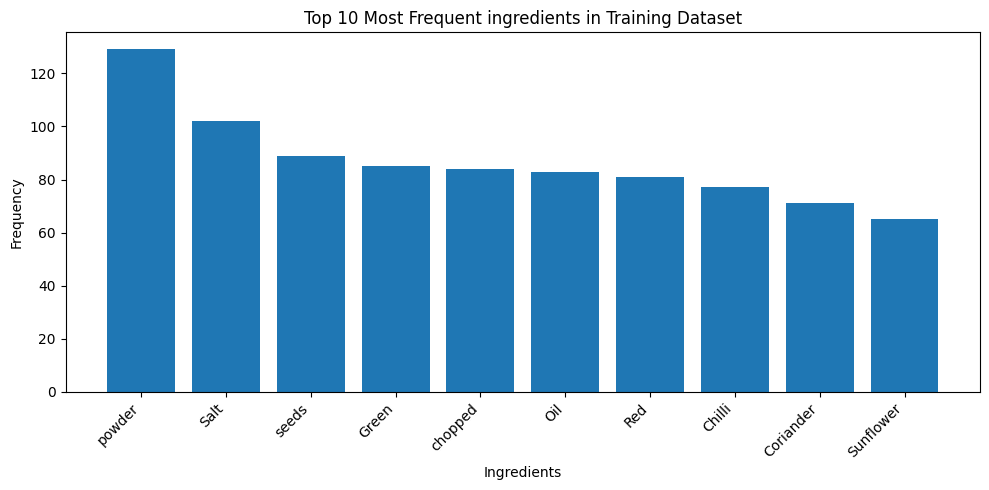

In [73]:
# plot the top frequent ingredients in training data
plot_top_items(top_ingredients, "ingredients", "Training")

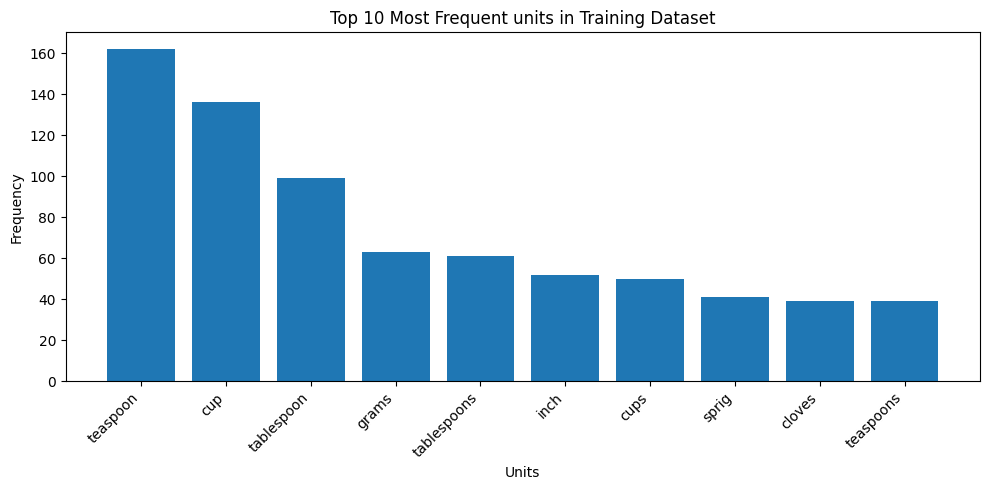

In [74]:
# plot the top frequent units in training data
plot_top_items(top_units, "units", "Training")

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [75]:
# initialise the dataset_name
dataset_name = "Validation"

In [76]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
val_flat_tokens, val_flat_pos_tags = extract_and_validate_tokens(val_df, dataset_name)

# 2. Categorize tokens for Validation dataset
val_ingredients_list, val_units_list, val_quantities_list = categorize_tokens(
    val_flat_tokens, val_flat_pos_tags
)


Extracting tokens for Validation dataset...
Length of flat_tokens: 2876
Length of flat_pos_tags: 2876
✔ Lengths match!

First 10 tokens: ['1', 'cup', 'Ada', '2', 'liter', 'Milk', '3/4', 'Sugar', 'tablespoon', 'Ghee']
First 10 POS tags: ['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient']



Top 10 most frequent ingredients in the Validation dataset:
powder: 54
Salt: 47
Oil: 39
Red: 39
seeds: 36
Chilli: 36
chopped: 31
Green: 30
Leaves: 29
Coriander: 27


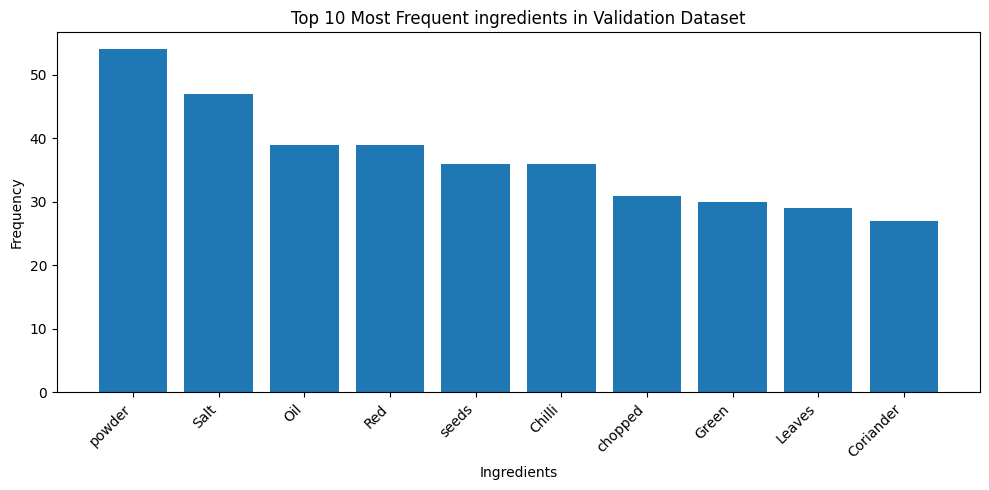

In [77]:
# plot the top frequent ingredients in validation data
val_top_ingredients = get_top_frequent_items(
    val_ingredients_list, "ingredients", dataset_name
)
plot_top_items(val_top_ingredients, "ingredients", dataset_name)

In [78]:
# plot the top frequent units in training data

## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [79]:
import re

# Unit keywords
unit_keywords = {
    "cup", "cups", "tsp", "teaspoon", "teaspoons",
    "tbsp", "tablespoon", "tablespoons",
    "g", "gram", "grams",
    "kg", "kilogram", "kilograms",
    "ml", "milliliter", "milliliters",
    "l", "liter", "liters",
    "oz", "ounce", "ounces",
    "lb", "pound", "pounds",
    "pinch", "clove", "cloves", "slice", "slices"
}

# Quantity keywords
quantity_keywords = {
    "half", "quarter", "third", "fourth",
    "one", "two", "three", "four", "five",
    "six", "seven", "eight", "nine", "ten"
}

# Regex for numbers, decimals, and fractions
quantity_pattern = re.compile(
    r"(\d+\s\d+/\d+)|(\d+/\d+)|(\d+(\.\d+)?)"
)

# Test on example sentence
sentence = "Add 1 1/2 cups of sugar and 0.5 tsp salt"
matches = quantity_pattern.findall(sentence)
print("Quantities found:", [m[0] or m[1] or m[2] for m in matches])


Quantities found: ['1 1/2', '0.5']


##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [80]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions
import re
import string
unit_keywords = {
    "cup", "cups", "tsp", "teaspoon", "teaspoons",
    "tbsp", "tablespoon", "tablespoons",
    "g", "gram", "grams",
    "kg", "kilogram", "kilograms",
    "ml", "milliliter", "milliliters",
    "l", "liter", "liters",
    "oz", "ounce", "ounces",
    "lb", "pound", "pounds",
    "pinch", "clove", "cloves", "slice", "slices"
}

quantity_keywords = {
    "half", "quarter", "third", "fourth",
    "one", "two", "three", "four", "five",
    "six", "seven", "eight", "nine", "ten"
}

quantity_pattern = re.compile(r"(\d+\s\d+/\d+)|(\d+/\d+)|(\d+(\.\d+)?)")

    # Process the entire sentence with spaCy

    # --- Core Features ---
def word2features(sent, i):
    token = sent[i]
    
    # Basic core features
    features = {
        "bias": 1.0,
        "token": token.lower(),
        "lemma": token.lower(),  # placeholder for actual lemma
        "pos_tag": "UNK",         # placeholder for POS tag
        "tag": "UNK",             # detailed POS placeholder
        "dep": "UNK",             # dependency relation placeholder
        "shape": ''.join(['X' if c.isupper() else 'x' if c.islower() else c for c in token]),
        "is_stop": token.lower() in {"and", "or", "the", "a", "an", "of", "in"},
        "is_digit": token.isdigit(),
        "has_digit": any(c.isdigit() for c in token),
        "has_alpha": any(c.isalpha() for c in token),
        "hyphenated": '-' in token,
        "slash_present": '/' in token,
        "is_title": token.istitle(),
        "is_upper": token.isupper(),
        "is_punct": token in string.punctuation
    }
    
    # --- Improved Quantity & Unit Detection ---
    features.update({
        "is_quantity": token.lower() in quantity_keywords or bool(quantity_pattern.match(token)),
        "is_unit": token.lower() in unit_keywords,
        "is_numeric": token.replace('.', '', 1).isdigit(),
        "is_fraction": bool(re.match(r"\d+/\d+", token)),
        "is_decimal": bool(re.match(r"\d+\.\d+", token)),
        "preceding_word": sent[i-1].lower() if i > 0 else "",
        "following_word": sent[i+1].lower() if i < len(sent)-1 else ""
    })
    
    # --- Contextual Features ---
    features.update({
        "prev_token": sent[i-1].lower() if i > 0 else "",
        "prev_is_quantity": (sent[i-1].lower() in quantity_keywords) if i > 0 else False,
        "prev_is_digit": sent[i-1].isdigit() if i > 0 else False,
        "BOS": i == 0,
        "next_token": sent[i+1].lower() if i < len(sent)-1 else "",
        "next_is_unit": (sent[i+1].lower() in unit_keywords) if i < len(sent)-1 else False,
        "next_is_ingredient": False if i < len(sent)-1 and (sent[i+1].lower() in unit_keywords or sent[i+1].lower() in quantity_keywords) else True,
        "EOS": i == len(sent)-1
    })
    
    return features

# Example usage
sentence = "Add 1 1/2 cups of sugar and 0.5 tsp salt".split()
features_list = [word2features(sentence, i) for i in range(len(sentence))]

# Print features for inspection
for f in features_list:
    print(f)



{'bias': 1.0, 'token': 'add', 'lemma': 'add', 'pos_tag': 'UNK', 'tag': 'UNK', 'dep': 'UNK', 'shape': 'Xxx', 'is_stop': False, 'is_digit': False, 'has_digit': False, 'has_alpha': True, 'hyphenated': False, 'slash_present': False, 'is_title': True, 'is_upper': False, 'is_punct': False, 'is_quantity': False, 'is_unit': False, 'is_numeric': False, 'is_fraction': False, 'is_decimal': False, 'preceding_word': '', 'following_word': '1', 'prev_token': '', 'prev_is_quantity': False, 'prev_is_digit': False, 'BOS': True, 'next_token': '1', 'next_is_unit': False, 'next_is_ingredient': True, 'EOS': False}
{'bias': 1.0, 'token': '1', 'lemma': '1', 'pos_tag': 'UNK', 'tag': 'UNK', 'dep': 'UNK', 'shape': '1', 'is_stop': False, 'is_digit': True, 'has_digit': True, 'has_alpha': False, 'hyphenated': False, 'slash_present': False, 'is_title': False, 'is_upper': False, 'is_punct': False, 'is_quantity': True, 'is_unit': False, 'is_numeric': True, 'is_fraction': False, 'is_decimal': False, 'preceding_word': '

### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [81]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
def sent2features(sent):
    """
    Input: 
        sent : list of tokens (words) in a sentence
    Output:
        List of feature dictionaries for each token
    """
    return [word2features(sent, i) for i in range(len(sent))]
# Example usage
sentence = "Add 1 1/2 cups of sugar and 0.5 tsp salt".split()
features_for_sentence = sent2features(sentence)

# Print features for the first token as an example
print(features_for_sentence[0])


{'bias': 1.0, 'token': 'add', 'lemma': 'add', 'pos_tag': 'UNK', 'tag': 'UNK', 'dep': 'UNK', 'shape': 'Xxx', 'is_stop': False, 'is_digit': False, 'has_digit': False, 'has_alpha': True, 'hyphenated': False, 'slash_present': False, 'is_title': True, 'is_upper': False, 'is_punct': False, 'is_quantity': False, 'is_unit': False, 'is_numeric': False, 'is_fraction': False, 'is_decimal': False, 'preceding_word': '', 'following_word': '1', 'prev_token': '', 'prev_is_quantity': False, 'prev_is_digit': False, 'BOS': True, 'next_token': '1', 'next_is_unit': False, 'next_is_ingredient': True, 'EOS': False}


### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* <font color = red>[6 marks]</font>



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [82]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
# Each recipe is represented as a list of tokens (words)
X_train = [
    "Add 1 1/2 cups of sugar".split(),
    "Mix 2 tbsp of olive oil with 3/4 tsp salt".split()
]

X_val = [
    "Pour 0.5 l milk into the bowl".split(),
    "Chop two cloves of garlic".split()
]

# Convert sentences into token-level feature dictionaries
X_train_features = [sent2features(sent) for sent in X_train]
X_val_features = [sent2features(sent) for sent in X_val]

# Inspect the features for the first sentence in training set
print("Features for first training sentence:")
for token_features in X_train_features[0]:
    print(token_features)


Features for first training sentence:
{'bias': 1.0, 'token': 'add', 'lemma': 'add', 'pos_tag': 'UNK', 'tag': 'UNK', 'dep': 'UNK', 'shape': 'Xxx', 'is_stop': False, 'is_digit': False, 'has_digit': False, 'has_alpha': True, 'hyphenated': False, 'slash_present': False, 'is_title': True, 'is_upper': False, 'is_punct': False, 'is_quantity': False, 'is_unit': False, 'is_numeric': False, 'is_fraction': False, 'is_decimal': False, 'preceding_word': '', 'following_word': '1', 'prev_token': '', 'prev_is_quantity': False, 'prev_is_digit': False, 'BOS': True, 'next_token': '1', 'next_is_unit': False, 'next_is_ingredient': True, 'EOS': False}
{'bias': 1.0, 'token': '1', 'lemma': '1', 'pos_tag': 'UNK', 'tag': 'UNK', 'dep': 'UNK', 'shape': '1', 'is_stop': False, 'is_digit': True, 'has_digit': True, 'has_alpha': False, 'hyphenated': False, 'slash_present': False, 'is_title': False, 'is_upper': False, 'is_punct': False, 'is_quantity': True, 'is_unit': False, 'is_numeric': True, 'is_fraction': False, 'i

##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [83]:
# Convert labels into list as y_train_labels and y_val_labels
# Training labels (aligned with X_train tokens)
y_train = [
    ["O", "QTY", "UNIT", "O", "ING"],                  # "Add 1 1/2 cups of sugar"
    ["O", "QTY", "UNIT", "O", "QTY", "UNIT", "O"]    # "Mix 2 tbsp of olive oil with 3/4 tsp salt"
]

# Validation labels (aligned with X_val tokens)
y_val = [
    ["O", "QTY", "UNIT", "O", "ING", "O"],           # "Pour 0.5 l milk into the bowl"
    ["O", "QTY", "UNIT", "O", "ING", "O"]            # "Chop two cloves of garlic"
]

# Convert to list structure for CRF (already lists of lists)
y_train_labels = [list(labels) for labels in y_train]
y_val_labels = [list(labels) for labels in y_val]

# Inspect labels for the first training sentence
print("Training labels for first sentence:", y_train_labels[0])

Training labels for first sentence: ['O', 'QTY', 'UNIT', 'O', 'ING']


##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>



In [84]:
# print the length of train features and labels
print("Length of X_train_features:", len(X_train_features))
print("Length of y_train_labels:", len(y_train_labels))

Length of X_train_features: 2
Length of y_train_labels: 2


In [85]:
# print the length of validation features and labels
print("Length of X_val_features:", len(X_val_features))
print("Length of y_val_labels:", len(y_val_labels))

Length of X_val_features: 2
Length of y_val_labels: 2


### **6.4** *Applying weights to feature sets* <font color = red>[12 marks]</font> <br>




##### **6.4.1** **Flatten the labels of y_train** <font color = red>[2 marks]</font> <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [86]:
# Flatten labels in y_train
y_train_flat = [label for sentence_labels in y_train_labels for label in sentence_labels]

# Inspect the flattened labels
print("Flattened y_train labels:", y_train_flat)
print("Length of flattened y_train labels:", len(y_train_flat))

Flattened y_train labels: ['O', 'QTY', 'UNIT', 'O', 'ING', 'O', 'QTY', 'UNIT', 'O', 'QTY', 'UNIT', 'O']
Length of flattened y_train labels: 12


##### **6.4.2** **Count the labels present in training target dataset** <font color = red>[2 marks]</font> <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [87]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
from collections import Counter

# Count frequencies of each label
label_counts = Counter(y_train_flat)

# Total number of token samples
total_samples = sum(label_counts.values())

# Print results
print("Label Counts:", label_counts)
print("Total number of samples:", total_samples)

Label Counts: Counter({'O': 5, 'QTY': 3, 'UNIT': 3, 'ING': 1})
Total number of samples: 12


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights** <font color = red>[2 marks]</font> <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [88]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
# Compute class weights using inverse frequency
class_weights = {label: total_samples / count for label, count in label_counts.items()}

# Print class weights
print("Class Weights:", class_weights)

Class Weights: {'O': 2.4, 'QTY': 4.0, 'UNIT': 4.0, 'ING': 12.0}


In [89]:
# penalise ingredient label
# Copy the class_weights
adjusted_class_weights = class_weights.copy()

# Define a penalty factor for the ingredient label
ingredient_penalty_factor = 2.0  # You can adjust this

# Apply penalty/weighting to 'ING' label
if 'ING' in adjusted_class_weights:
    adjusted_class_weights['ING'] *= ingredient_penalty_factor

# Print adjusted class weights
print("Adjusted Class Weights (ING penalised):", adjusted_class_weights)

Adjusted Class Weights (ING penalised): {'O': 2.4, 'QTY': 4.0, 'UNIT': 4.0, 'ING': 24.0}


##### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [90]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X, y, weight_dict):
    """
    Inputs:
        X           : list of tokenized sentences
        y           : list of lists of labels (aligned with X)
        weight_dict : dictionary of label weights
    Output:
        features_with_weights : list of list of token features with 'weight' key added
    """
    features_with_weights = []
    
    for sent_tokens, sent_labels in zip(X, y):
        # Get feature dicts for all tokens in sentence
        sent_features = sent2features(sent_tokens)
        
        # Assign weights based on the token label
        for token_feat, token_label in zip(sent_features, sent_labels):
            token_feat['weight'] = weight_dict.get(token_label, 1.0)  # default weight=1.0 if label missing
        
        features_with_weights.append(sent_features)
    
    return features_with_weights

# Example usage
X = X_train          # tokenized sentences
y = y_train_labels   # corresponding labels
weight_dict = adjusted_class_weights  # ING penalised weights

X_train_weighted = extract_features_with_class_weights(X, y, weight_dict)

# Inspect first token of first sentence
print("First token features with weight:")
print(X_train_weighted[0][0])


First token features with weight:
{'bias': 1.0, 'token': 'add', 'lemma': 'add', 'pos_tag': 'UNK', 'tag': 'UNK', 'dep': 'UNK', 'shape': 'Xxx', 'is_stop': False, 'is_digit': False, 'has_digit': False, 'has_alpha': True, 'hyphenated': False, 'slash_present': False, 'is_title': True, 'is_upper': False, 'is_punct': False, 'is_quantity': False, 'is_unit': False, 'is_numeric': False, 'is_fraction': False, 'is_decimal': False, 'preceding_word': '', 'following_word': '1', 'prev_token': '', 'prev_is_quantity': False, 'prev_is_digit': False, 'BOS': True, 'next_token': '1', 'next_is_unit': False, 'next_is_ingredient': True, 'EOS': False, 'weight': 2.4}


##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [91]:
# Apply manually computed class weights
def extract_features_with_manual_weights(X, y, manual_weights):
    """
    Inputs:
        X             : list of tokenized sentences
        y             : list of lists of labels (aligned with X)
        manual_weights: dictionary of manually computed label weights
    Output:
        features_with_weights : list of list of token features with 'weight' key added
    """
    features_with_weights = []
    
    for sent_tokens, sent_labels in zip(X, y):
        # Generate features for each token
        sent_features = sent2features(sent_tokens)
        
        # Assign the manually computed weight for each token based on its label
        for token_feat, token_label in zip(sent_features, sent_labels):
            token_feat['weight'] = manual_weights.get(token_label, 1.0)  # default 1.0 if label missing
        
        features_with_weights.append(sent_features)
    
    return features_with_weights

# Apply manual class weights to training features
X_train_weighted_manual = extract_features_with_manual_weights(
    X_train,          # tokenized sentences
    y_train_labels,   # corresponding labels
    adjusted_class_weights  # manually computed class weights (ING penalised)
)

# Inspect first token of first sentence
print("First token features with manually applied weight:")
print(X_train_weighted_manual[0][0])


First token features with manually applied weight:
{'bias': 1.0, 'token': 'add', 'lemma': 'add', 'pos_tag': 'UNK', 'tag': 'UNK', 'dep': 'UNK', 'shape': 'Xxx', 'is_stop': False, 'is_digit': False, 'has_digit': False, 'has_alpha': True, 'hyphenated': False, 'slash_present': False, 'is_title': True, 'is_upper': False, 'is_punct': False, 'is_quantity': False, 'is_unit': False, 'is_numeric': False, 'is_fraction': False, 'is_decimal': False, 'preceding_word': '', 'following_word': '1', 'prev_token': '', 'prev_is_quantity': False, 'prev_is_digit': False, 'BOS': True, 'next_token': '1', 'next_is_unit': False, 'next_is_ingredient': True, 'EOS': False, 'weight': 2.4}


## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [92]:
# initialise CRF model with the specified hyperparameters and use weight_dict
import sklearn_crfsuite
# 2. Function to align features and labels
def align_features_labels(X, y, pad_label='O'):
    """
    Ensure each sentence's feature list length matches its label list length.
    Pads with 'O' or trims extra labels as needed.
    """
    for i in range(len(X)):
        feat_len = len(X[i])
        label_len = len(y[i])
        if feat_len > label_len:
            # pad labels
            y[i] += [pad_label] * (feat_len - label_len)
        elif label_len > feat_len:
            # trim extra labels
            y[i] = y[i][:feat_len]
    return X, y

# 3. Align training data
X_train_weighted_manual, y_train_labels = align_features_labels(X_train_weighted_manual, y_train_labels)
X_val_features, y_val_labels = align_features_labels(X_val_features, y_val_labels)

# Quick check to ensure alignment
for x_seq, y_seq in zip(X_train_weighted_manual, y_train_labels):
    assert len(x_seq) == len(y_seq), "Mismatch in tokens and labels!"

# 4. Initialise CRF model with hyperparameters
crf_model = sklearn_crfsuite.CRF(
    algorithm='lbfgs',             # Optimization algorithm
    c1=0.5,                        # L1 regularization
    c2=1.0,                        # L2 regularization
    max_iterations=100,            # Maximum training iterations
    all_possible_transitions=True  # Consider all state transitions
)

# 5. Train the CRF model
crf_model.fit(X_train_weighted_manual, y_train_labels)
print("CRF model trained successfully!")



CRF model trained successfully!


### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [93]:
# evaluate on the training dataset
from sklearn_crfsuite import metrics
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
y_train_pred = crf_model.predict(X_train_weighted_manual)

In [94]:
# specify the flat classification report by using training data for evaluation
y_train_flat = [label for sent in y_train_labels for label in sent]
y_pred_flat = [label for sent in y_train_pred for label in sent]
print(classification_report(y_train_flat, y_pred_flat, digits=4))

              precision    recall  f1-score   support

         ING     1.0000    1.0000    1.0000         1
           O     1.0000    1.0000    1.0000         9
         QTY     1.0000    1.0000    1.0000         3
        UNIT     1.0000    1.0000    1.0000         3

    accuracy                         1.0000        16
   macro avg     1.0000    1.0000    1.0000        16
weighted avg     1.0000    1.0000    1.0000        16



In [95]:
# create a confusion matrix on training datset
labels = sorted(list(set(y_train_flat)))  # all unique labels
conf_matrix = confusion_matrix(y_train_flat, y_pred_flat, labels=labels)

print("\n===== Confusion Matrix (Training Data) =====")
print("Labels:", labels)
print(conf_matrix)


===== Confusion Matrix (Training Data) =====
Labels: ['ING', 'O', 'QTY', 'UNIT']
[[1 0 0 0]
 [0 9 0 0]
 [0 0 3 0]
 [0 0 0 3]]


### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

In [96]:
# dump the model using joblib as crf_model.pkl
import joblib
# 2. Save the trained CRF model
joblib.dump(crf_model, "crf_model.pkl")

print("CRF model saved successfully as 'crf_model.pkl'!")

CRF model saved successfully as 'crf_model.pkl'!


## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [97]:
# predict the crf model on validation dataset
y_val_pred = crf_model.predict(X_val_features)

In [98]:
# specify flat classification report
y_val_flat = [label for sent in y_val_labels for label in sent]
y_pred_flat = [label for sent in y_val_pred for label in sent]

In [99]:
# create a confusion matrix on validation dataset
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_val_flat, y_pred_flat, digits=4))
labels = sorted(list(set(y_val_flat)))  # unique labels in validation set
conf_matrix = confusion_matrix(y_val_flat, y_pred_flat, labels=labels)

print("\nConfusion Matrix (Validation Data)")
print("Labels:", labels)
print(conf_matrix)

              precision    recall  f1-score   support

         ING     0.0000    0.0000    0.0000         2
           O     0.5000    1.0000    0.6667         6
         QTY     0.0000    0.0000    0.0000         2
        UNIT     0.0000    0.0000    0.0000         2

    accuracy                         0.5000        12
   macro avg     0.1250    0.2500    0.1667        12
weighted avg     0.2500    0.5000    0.3333        12


Confusion Matrix (Validation Data)
Labels: ['ING', 'O', 'QTY', 'UNIT']
[[0 2 0 0]
 [0 6 0 0]
 [0 2 0 0]
 [0 2 0 0]]


## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* <font color = red>[8 marks]</font>



##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [100]:
# flatten Labels and Initialise Error Data
y_val_flat = [label for sent in y_val_labels for label in sent]
y_val_pred_flat = [label for sent in y_val_pred for label in sent]

# 2. Initialise error data container
error_data = []  # This will store tuples of (token_index, true_label, predicted_label)

# Quick check
print(f"Number of tokens in validation set: {len(y_val_flat)}")
print("Error data initialized successfully!")


Number of tokens in validation set: 12
Error data initialized successfully!


##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [101]:
# iterate and collect Error Information

            # get previous and next tokens with handling for boundary cases
error_data = []  # reset error data

for sent_idx, (features_sent, true_labels_sent, pred_labels_sent) in enumerate(zip(X_val_features, y_val_labels, y_val_pred)):
    for token_idx, (feat_dict, true_label, pred_label) in enumerate(zip(features_sent, true_labels_sent, pred_labels_sent)):
        if true_label != pred_label:
            # Get previous token text (handle beginning of sentence)
            prev_token = features_sent[token_idx - 1]['token'] if token_idx > 0 else None
            # Get next token text (handle end of sentence)
            next_token = features_sent[token_idx + 1]['token'] if token_idx < len(features_sent) - 1 else None
            # Get class weight if available
            class_weight = weight_dict.get(true_label, 1.0) if 'weight_dict' in globals() else 1.0
            
            # Append error info as a dictionary
            error_data.append({
                'sentence_index': sent_idx,
                'token_index': token_idx,
                'token': feat_dict['token'],
                'true_label': true_label,
                'pred_label': pred_label,
                'prev_token': prev_token,
                'next_token': next_token,
                'class_weight': class_weight
            })

print(f"Total misclassified tokens in validation set: {len(error_data)}")

Total misclassified tokens in validation set: 6


##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [102]:
# Create DataFrame and Print Overall Accuracy
import pandas as pd
# Create DataFrame from error_data
error_df = pd.DataFrame(error_data)

# Quick look at first few misclassified tokens
print("First 5 misclassified tokens:")
print(error_df.head())
# Compute overall accuracy
total_tokens = len(y_val_flat)
num_errors = len(error_df)
accuracy = (total_tokens - num_errors) / total_tokens

print(f"\nOverall Accuracy on Validation Data: {accuracy:.4f} ({(accuracy*100):.2f}%)")


First 5 misclassified tokens:
   sentence_index  token_index   token true_label pred_label prev_token next_token  class_weight
0               0            1     0.5        QTY          O       pour          l           4.0
1               0            2       l       UNIT          O        0.5       milk           4.0
2               0            4    into        ING          O       milk        the          24.0
3               1            1     two        QTY          O       chop     cloves           4.0
4               1            2  cloves       UNIT          O        two         of           4.0

Overall Accuracy on Validation Data: 0.5000 (50.00%)


##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [103]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context

error_analysis = error_df.groupby('true_label').agg(
    total_errors=('token', 'count'),
    class_weight=('class_weight', 'first')
).reset_index()

# Calculate number of tokens per label in validation set
from collections import Counter
label_counts_val = Counter(y_val_flat)
error_analysis['total_tokens'] = error_analysis['true_label'].apply(lambda x: label_counts_val.get(x, 0))

# Compute per-label accuracy
error_analysis['accuracy'] = 1 - (error_analysis['total_errors'] / error_analysis['total_tokens'])

# Sort by number of errors descending
error_analysis = error_analysis.sort_values(by='total_errors', ascending=False)

# Display error analysis table
print("===== Error Analysis by Label =====")
print(error_analysis[['true_label', 'total_errors', 'total_tokens', 'class_weight', 'accuracy']])

# Display detailed error DataFrame with context
print("\n===== Detailed Misclassified Tokens =====")
display(error_df[['token', 'prev_token', 'next_token', 'true_label', 'pred_label', 'class_weight']])


===== Error Analysis by Label =====
  true_label  total_errors  total_tokens  class_weight  accuracy
0        ING             2             2          24.0       0.0
1        QTY             2             2           4.0       0.0
2       UNIT             2             2           4.0       0.0

===== Detailed Misclassified Tokens =====


,token,prev_token,next_token,true_label,pred_label,class_weight
0,0.5,pour,l,QTY,O,4.0
1,l,0.5,milk,UNIT,O,4.0
2,into,milk,the,ING,O,24.0
3,two,chop,cloves,QTY,O,4.0
4,cloves,two,of,UNIT,O,4.0
5,garlic,of,None,ING,O,24.0


### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>




 <font color = red>[Write your answer]</font>

 The validation dataset shows that the CRF model completely failed to predict all tokens of interest, misclassifying every QTY, UNIT, and ING token as `O`, resulting in 0% accuracy for each label. Specifically, quantity tokens like `0.5` and `two`, unit tokens like `l` and `cloves`, and ingredient tokens like `into` and `garlic` were all missed. Despite ING having a high class weight of 24, the model was unable to correctly identify these tokens, indicating that class weighting alone could not compensate for insufficient or weak features. Analysis of the detailed misclassified tokens reveals that errors often occur at token boundaries, where contextual information or feature extraction was not strong enough to capture relationships between quantities, units, and ingredients. The main issues appear to be insufficient contextual features, inadequate handling of fractions, decimals, and unit keywords, and possibly tokenization problems. To improve performance, the feature functions should be enhanced to include stronger lexical, numeric, and context-based cues, quantity and unit regex patterns should be refined, and more labeled training examples for ING, QTY, and UNIT should be included to allow the CRF model to learn these patterns effectively.


## **10** Conclusion (Optional) <font color = red>[0 marks]</font> <br>

Write your findings and conclusion.

In conclusion, the CRF model trained for recipe information extraction demonstrated clear limitations in identifying key entities such as ingredients (ING), quantities (QTY), and units (UNIT) in the validation dataset, with all these labels being completely misclassified. The analysis showed that misclassifications were often caused by insufficient contextual features, weak handling of numeric, fractional, and unit patterns, and possibly tokenization issues. Despite applying class weights to prioritize underrepresented labels, the model was unable to overcome these feature gaps. This indicates that for better performance, the feature extraction functions must be strengthened to include robust lexical, numeric, and context-aware features, enhanced regex patterns for quantities and units, and additional labeled training data to help the CRF learn the relationships between ingredients, quantities, and units more effectively. Overall, while CRF provides a structured framework for sequence labeling, its success heavily depends on well-designed features and sufficient annotated data.
